In [2]:
# MDI3003 – Advanced Predictive Analytics
## Experiment 1: House Price Prediction using Linear Regression

# Name: SHOBANA BALUSAMY
# Registration Number: 23MID0212

In [139]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [140]:
housing = fetch_california_housing()

X = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

y = pd.Series(
    housing.target,
    name="HouseValue"
)

In [141]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [142]:
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (20640, 8)
Target Shape   : (20640,)


In [143]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [144]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000


In [145]:
X.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [146]:
df = X.copy()
df["HouseValue"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


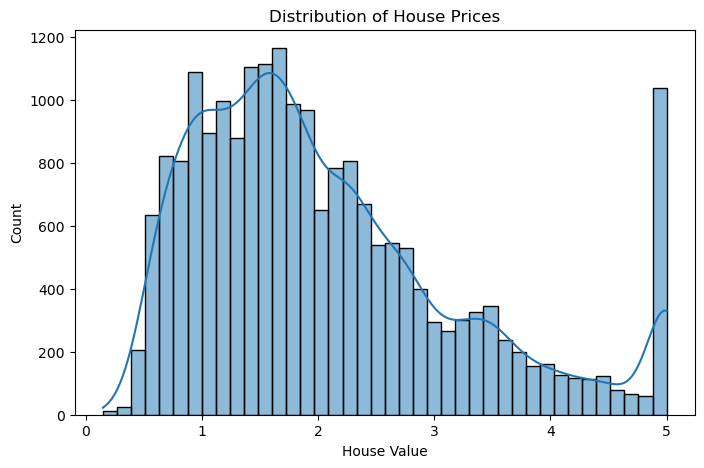

In [147]:
plt.figure(figsize=(8,5))

sns.histplot(df["HouseValue"], bins=40, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Value")
plt.ylabel("Count")

plt.show()

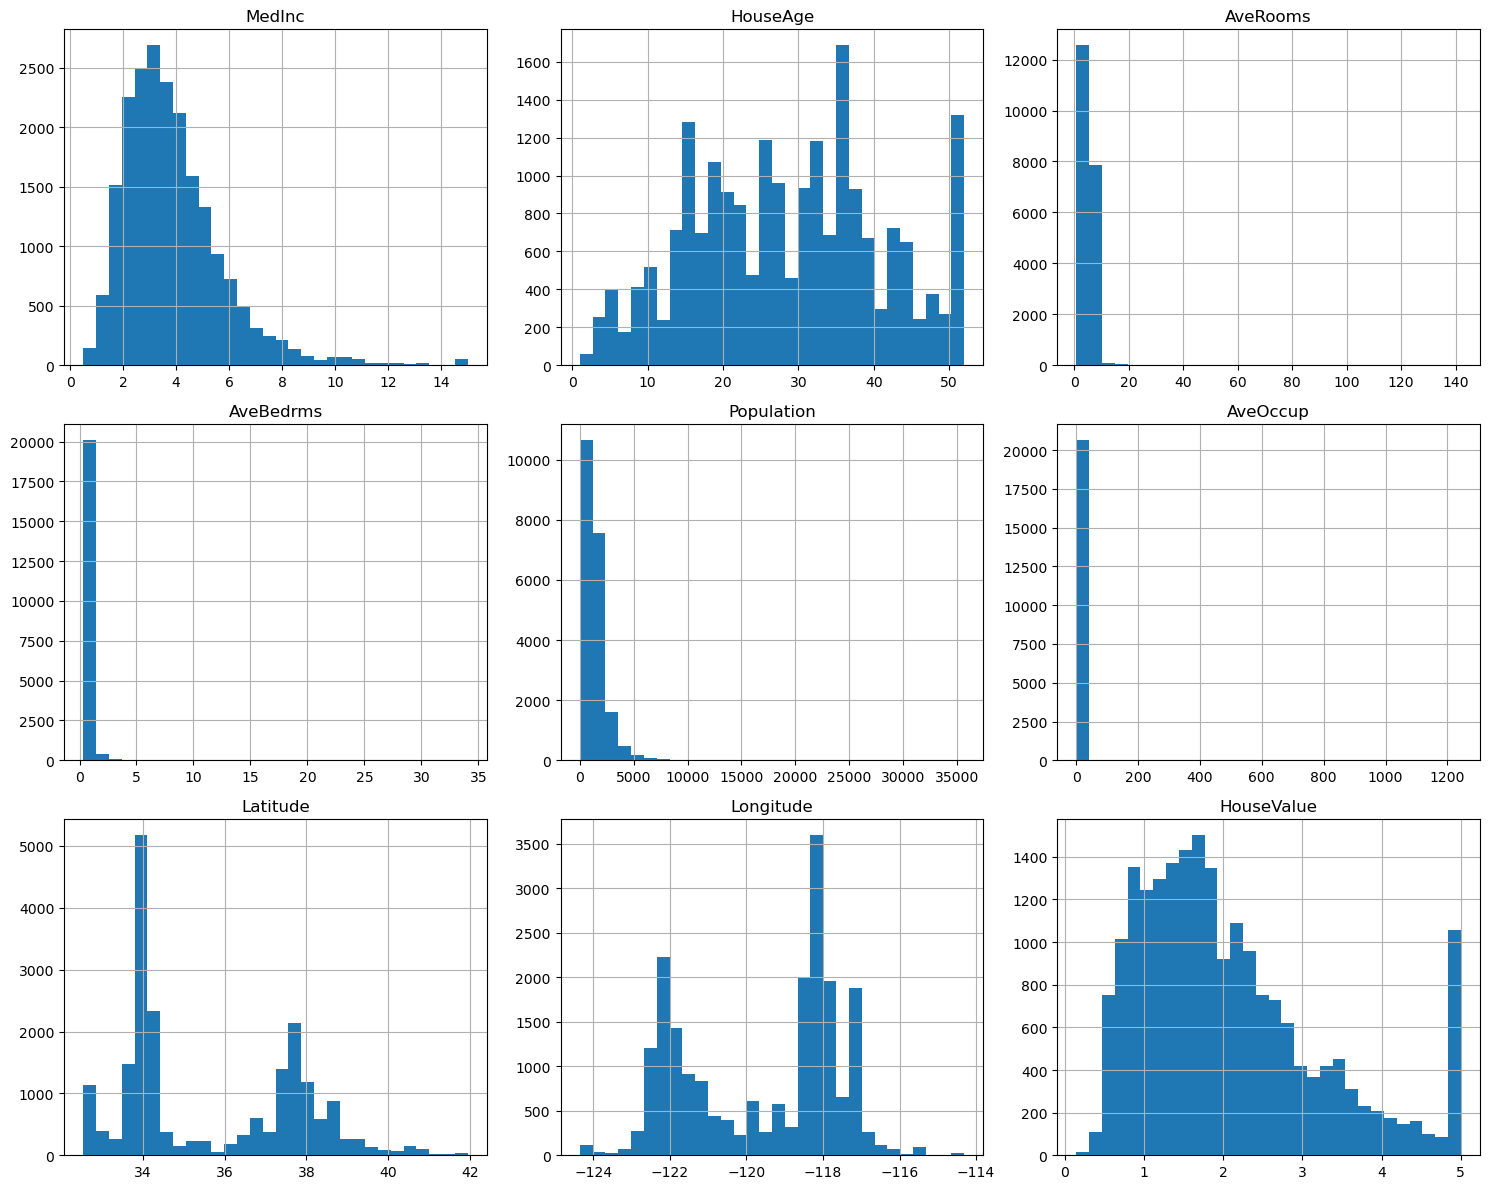

In [148]:
df.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

In [149]:
corr = df.corr()
corr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
HouseValue,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


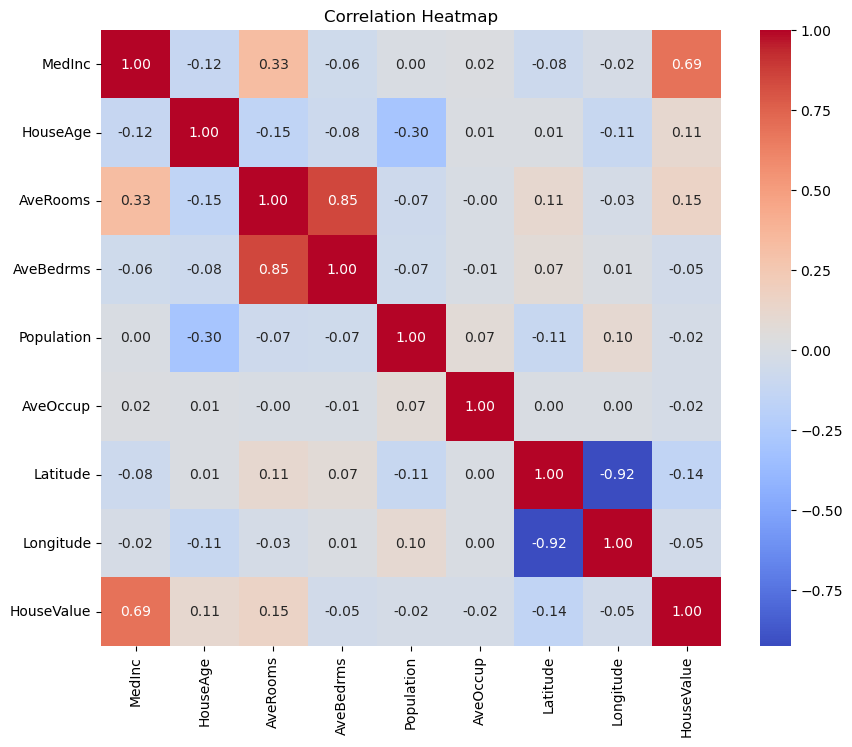

In [150]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

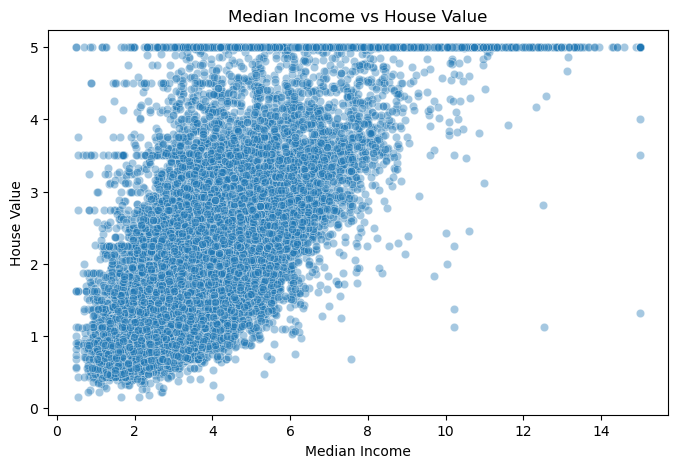

In [151]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["MedInc"],
    y=df["HouseValue"],
    alpha=0.4
)

plt.title("Median Income vs House Value")

plt.xlabel("Median Income")

plt.ylabel("House Value")

plt.show()

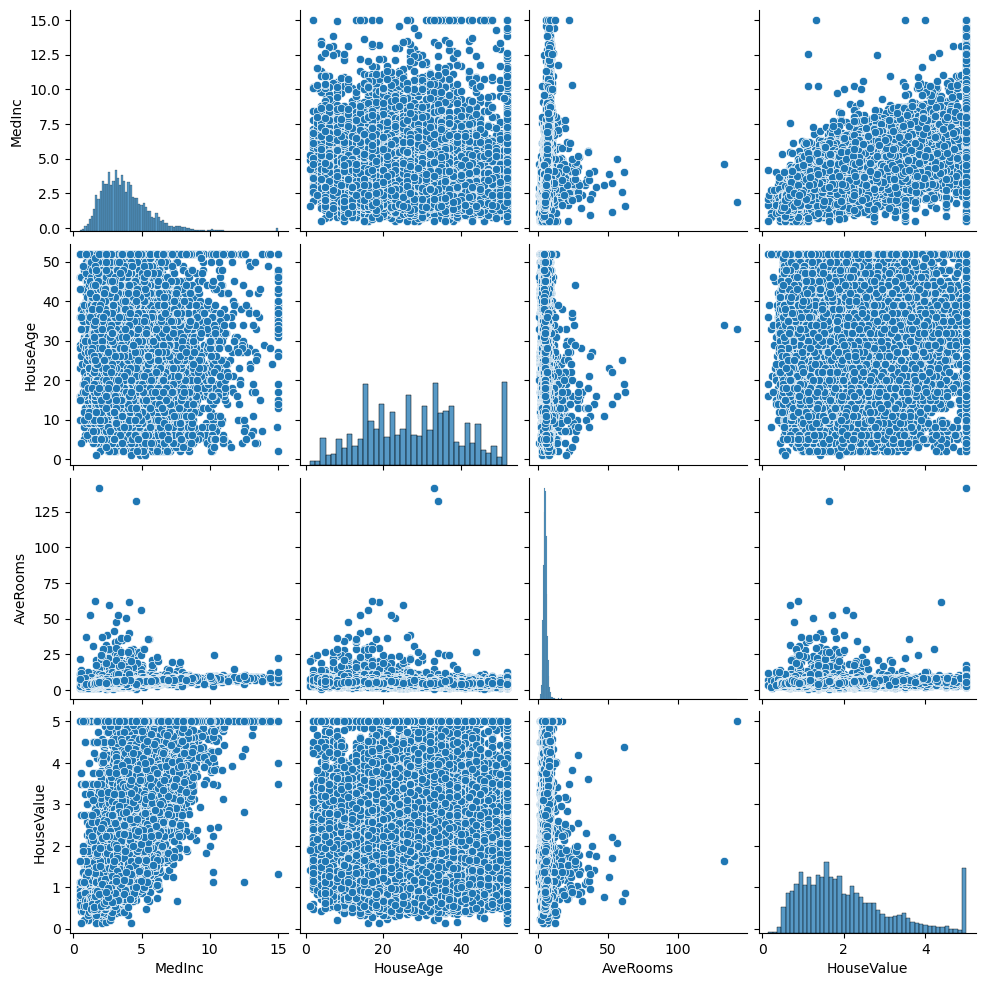

In [152]:
selected = df[
    [
        "MedInc",
        "HouseAge",
        "AveRooms",
        "HouseValue"
    ]
]

sns.pairplot(selected)
plt.show()

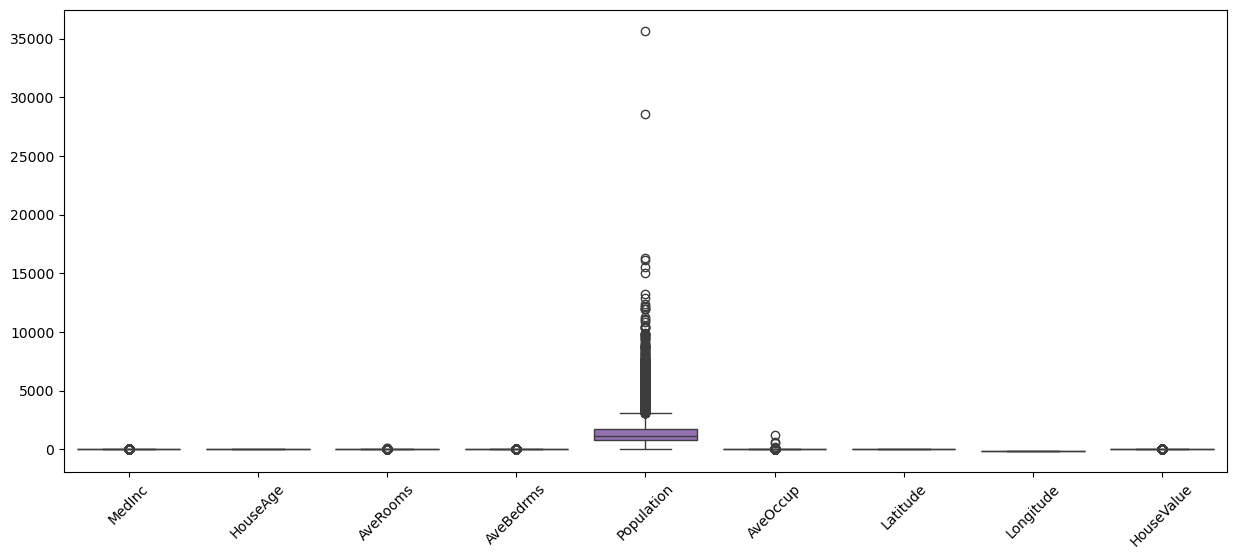

In [153]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)

plt.show()

In [154]:
## Exploratory Data Analysis (EDA)

### Observations

#- The dataset contains 20,640 observations and 8 numerical features.
#- No missing values were found.
#- The target variable (HouseValue) is slightly right-skewed.
#- Median Income (MedInc) has the strongest positive correlation with house prices.
#- Latitude and Longitude capture geographic variation in house prices.
#- Some variables contain outliers, but these will initially be retained because they represent genuine housing characteristics.

In [155]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (16512, 8)
Testing Set  : (4128, 8)


In [156]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [157]:
print("Original Data:")
print(X_train.head())

print("\nScaled Data:")
print(pd.DataFrame(X_train_scaled, columns=X.columns).head())

Original Data:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
14196  3.2596      33.0  5.017657   1.006421      2300.0  3.691814     32.71   
8267   3.8125      49.0  4.473545   1.041005      1314.0  1.738095     33.77   
17445  4.1563       4.0  5.645833   0.985119       915.0  2.723214     34.66   
14265  1.9425      36.0  4.002817   1.033803      1418.0  3.994366     32.69   
2271   3.5542      43.0  6.268421   1.134211       874.0  2.300000     36.78   

       Longitude  
14196    -117.03  
8267     -118.16  
17445    -120.48  
14265    -117.11  
2271     -119.80  

Scaled Data:
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0 -0.326196  0.348490 -0.174916  -0.208365    0.768276  0.051376 -1.372811   
1 -0.035843  1.618118 -0.402835  -0.128530   -0.098901 -0.117362 -0.876696   
2  0.144701 -1.952710  0.088216  -0.257538   -0.449818 -0.032280 -0.460146   
3 -1.017864  0.586545 -0.600015  -0.145156   -0.007434  0.077507

In [158]:
## Feature Scaling

# Feature scaling standardizes the numerical features to have a mean of 0 and a standard deviation of 1.

# Scaling is especially important for:
# - Ridge Regression
# - Lasso Regression

# Tree-based models such as Decision Tree and Random Forest do not require feature scaling, but the same train-test split is maintained for fair comparison.

In [159]:
results = pd.DataFrame(
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score",
        "Adjusted R2"
    ]
)

results

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2


In [160]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Calculate Adjusted R²
    n = len(y_test)          # Number of test samples
    p = X_test.shape[1]      # Number of predictor variables

    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

    global results

    results.loc[len(results)] = [
        model_name,
        mae,
        mse,
        rmse,
        r2,
        adjusted_r2
    ]

    print(f"\n{model_name}")
    print("-" * 40)
    print("MAE         :", round(mae, 4))
    print("MSE         :", round(mse, 4))
    print("RMSE        :", round(rmse, 4))
    print("R²          :", round(r2, 4))
    print("Adjusted R² :", round(adjusted_r2, 4))

    return model, y_pred

In [161]:
# Model 1 – Dummy Regressor (Baseline)

dummy = DummyRegressor(strategy="mean")

dummy_model, dummy_pred = evaluate_model(
    "Dummy Regressor",
    dummy,
    X_train,
    X_test,
    y_train,
    y_test
)


Dummy Regressor
----------------------------------------
MAE         : 0.9061
MSE         : 1.3107
RMSE        : 1.1449
R²          : -0.0002
Adjusted R² : -0.0022


In [162]:
# Model 2 – Simple Linear Regression

X_train_simple = X_train[["MedInc"]]
X_test_simple = X_test[["MedInc"]]

simple_lr = LinearRegression()

simple_model, simple_pred = evaluate_model(
    "Simple Linear Regression",
    simple_lr,
    X_train_simple,
    X_test_simple,
    y_train,
    y_test
)


Simple Linear Regression
----------------------------------------
MAE         : 0.6299
MSE         : 0.7091
RMSE        : 0.8421
R²          : 0.4589
Adjusted R² : 0.4587


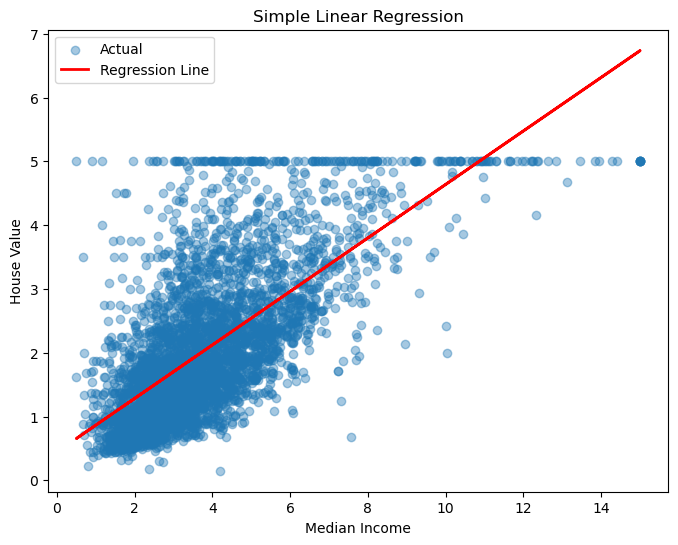

In [163]:
# Visualize the Simple Linear Regression

plt.figure(figsize=(8,6))

plt.scatter(
    X_test_simple,
    y_test,
    alpha=0.4,
    label="Actual"
)

plt.plot(
    X_test_simple,
    simple_pred,
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Simple Linear Regression")

plt.legend()

plt.show()

In [164]:
# Model 3 – Multiple Linear Regression

multiple_lr = LinearRegression()

multiple_model, multiple_pred = evaluate_model(
    "Multiple Linear Regression",
    multiple_lr,
    X_train,
    X_test,
    y_train,
    y_test
)


Multiple Linear Regression
----------------------------------------
MAE         : 0.5332
MSE         : 0.5559
RMSE        : 0.7456
R²          : 0.5758
Adjusted R² : 0.575


In [165]:
## Linear Regression Models

### Dummy Regressor : The Dummy Regressor predicts the mean target value and serves as a baseline.
### Simple Linear Regression : Uses only the `MedInc` feature to predict house prices.
### Multiple Linear Regression : Uses all available numerical features to model house prices and typically performs better than Simple Linear Regression.

In [166]:
# Model 4 – Ridge Regression

ridge = Ridge(alpha=1.0, random_state=42)

ridge_model, ridge_pred = evaluate_model(
    "Ridge Regression",
    ridge,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)


Ridge Regression
----------------------------------------
MAE         : 0.5332
MSE         : 0.5559
RMSE        : 0.7456
R²          : 0.5758
Adjusted R² : 0.575


In [167]:
# Model 5 – Lasso Regression

lasso = Lasso(alpha=0.01, random_state=42)

lasso_model, lasso_pred = evaluate_model(
    "Lasso Regression",
    lasso,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)


Lasso Regression
----------------------------------------
MAE         : 0.5353
MSE         : 0.5483
RMSE        : 0.7404
R²          : 0.5816
Adjusted R² : 0.5808


In [168]:
# Model 6 – Decision Tree Regressor

tree = DecisionTreeRegressor(
    random_state=42
)

tree_model, tree_pred = evaluate_model(
    "Decision Tree",
    tree,
    X_train,
    X_test,
    y_train,
    y_test
)


Decision Tree
----------------------------------------
MAE         : 0.4547
MSE         : 0.4952
RMSE        : 0.7037
R²          : 0.6221
Adjusted R² : 0.6213


In [169]:
# Model 7 – Random Forest Regressor

forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

forest_model, forest_pred = evaluate_model(
    "Random Forest",
    forest,
    X_train,
    X_test,
    y_train,
    y_test
)


Random Forest
----------------------------------------
MAE         : 0.3275
MSE         : 0.2554
RMSE        : 0.5053
R²          : 0.8051
Adjusted R² : 0.8047


In [170]:
results

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
0,Dummy Regressor,0.906069,1.310696,1.144856,-0.000219,-0.002162
1,Simple Linear Regression,0.629909,0.709116,0.842090,0.458859,0.458728
2,Multiple Linear Regression,0.533200,0.555892,0.745581,0.575788,0.574964
3,Ridge Regression,0.533193,0.555855,0.745557,0.575816,0.574992
4,Lasso Regression,0.535326,0.548255,0.740442,0.581615,0.580803
5,Decision Tree,0.454679,0.495235,0.703729,0.622076,0.621342
6,Random Forest,0.327543,0.255368,0.505340,0.805123,0.804745


In [171]:
results.round(4)

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
0,Dummy Regressor,0.9061,1.3107,1.1449,-0.0002,-0.0022
1,Simple Linear Regression,0.6299,0.7091,0.8421,0.4589,0.4587
2,Multiple Linear Regression,0.5332,0.5559,0.7456,0.5758,0.5750
3,Ridge Regression,0.5332,0.5559,0.7456,0.5758,0.5750
4,Lasso Regression,0.5353,0.5483,0.7404,0.5816,0.5808
5,Decision Tree,0.4547,0.4952,0.7037,0.6221,0.6213
6,Random Forest,0.3275,0.2554,0.5053,0.8051,0.8047


In [172]:
best_model = results.loc[
    results["R2 Score"].idxmax()
]

print(best_model)

Model          Random Forest
MAE                 0.327543
MSE                 0.255368
RMSE                 0.50534
R2 Score            0.805123
Adjusted R2         0.804745
Name: 6, dtype: object


In [173]:
results = results.sort_values(
    by="R2 Score",
    ascending=False
)

results.reset_index(
    drop=True,
    inplace=True
)

results.round(4)

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
0,Random Forest,0.3275,0.2554,0.5053,0.8051,0.8047
1,Decision Tree,0.4547,0.4952,0.7037,0.6221,0.6213
2,Lasso Regression,0.5353,0.5483,0.7404,0.5816,0.5808
3,Ridge Regression,0.5332,0.5559,0.7456,0.5758,0.5750
4,Multiple Linear Regression,0.5332,0.5559,0.7456,0.5758,0.5750
5,Simple Linear Regression,0.6299,0.7091,0.8421,0.4589,0.4587
6,Dummy Regressor,0.9061,1.3107,1.1449,-0.0002,-0.0022


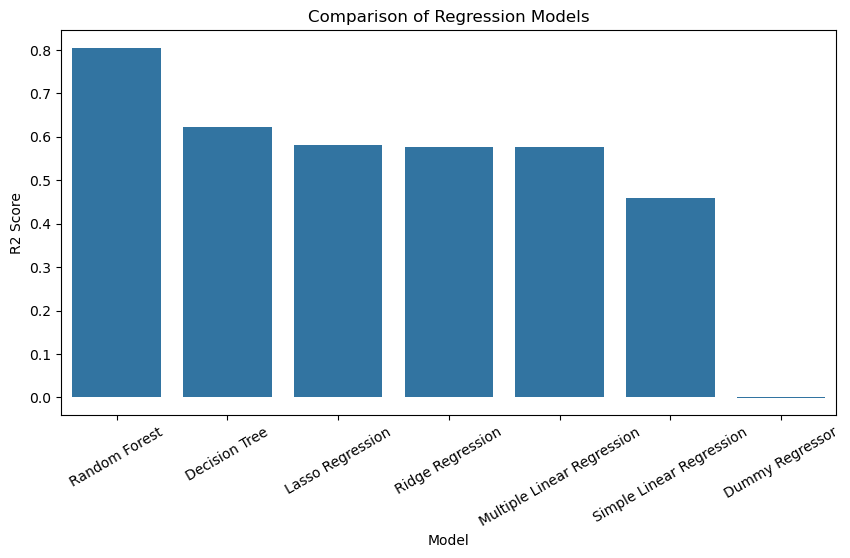

In [174]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.xticks(rotation=30)

plt.title("Comparison of Regression Models")

plt.show()

In [175]:
## Model Comparison

# Seven regression models were evaluated using the same train-test split.

# The comparison was based on:

# - Mean Absolute Error (MAE)
# - Mean Squared Error (MSE)
# - Root Mean Squared Error (RMSE)
# - Coefficient of Determination (R²)
# - Adjusted R² 
# The model with the highest R² score and lowest prediction errors was selected as the best-performing model.

In [176]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [177]:
print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest Cross Validation Score:")
print(grid_rf.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Score:
0.8050524232098117


In [178]:
best_rf = grid_rf.best_estimator_

y_pred_best = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_best)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 0.3271140672274751
RMSE: 0.5045713885354675
R² : 0.8057153985083529


In [51]:
cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R²:")
print(cv_scores.mean())

Cross Validation Scores:
[0.51768155 0.70463399 0.74213274 0.62696194 0.6822651 ]

Average R²:
0.6547350641391212


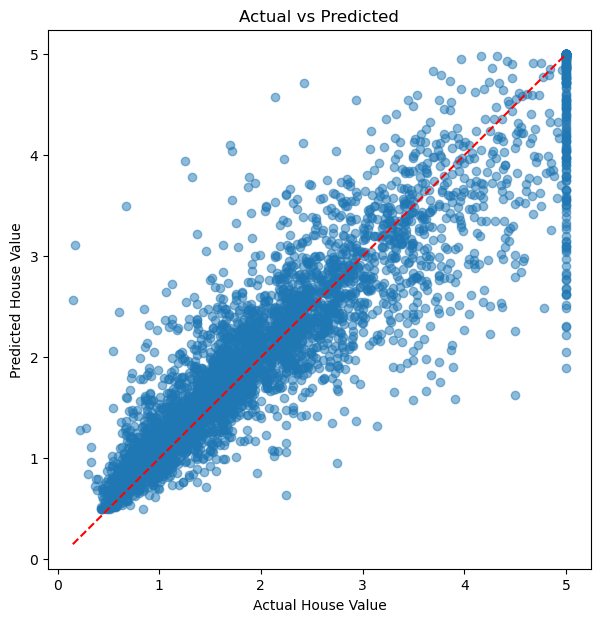

In [52]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted")

plt.show()

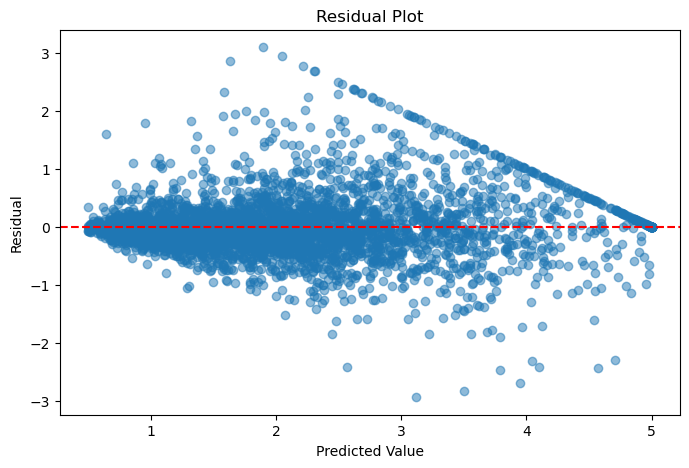

In [53]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_best,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Value")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

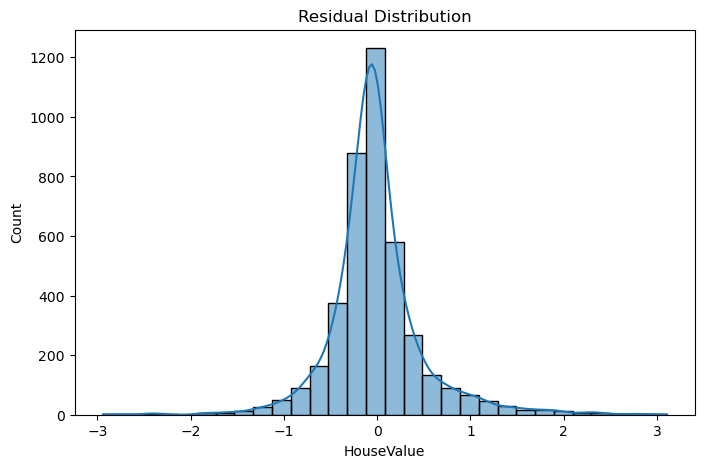

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

In [55]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,MedInc,0.526842
5,AveOccup,0.138143
6,Latitude,0.088633
7,Longitude,0.088177
1,HouseAge,0.054128
2,AveRooms,0.044249
4,Population,0.030494
3,AveBedrms,0.029334


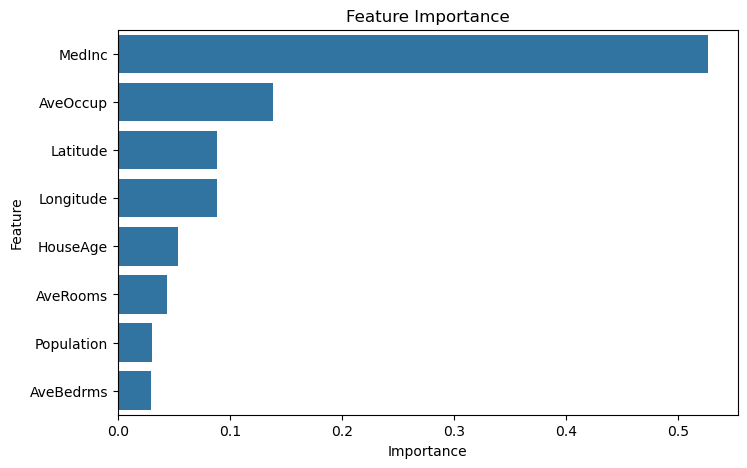

In [56]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [57]:
results.to_csv(
    "model_comparison_results.csv",
    index=False
)

importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [58]:
# Conclusion

# - Seven regression models were implemented and compared.
# - The models were evaluated using MAE, MSE, RMSE, R² Score and Adjusted R2.
# - Hyperparameter tuning was performed using GridSearchCV.
# - Cross-validation was used to assess model stability.
# - The Random Forest Regressor achieved the best predictive performance on the California Housing dataset.
# - Feature importance analysis showed that Median Income was the most influential predictor of house prices.

In [179]:
# Dataset 2

In [197]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [198]:
ames = fetch_openml(
    name="house_prices",
    as_frame=True
)

df = ames.frame.copy()

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [199]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (1460, 81)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  Over

In [200]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [201]:
df.describe(include="object")

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


In [202]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(
    ascending=False
).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
MasVnrType         8
Electrical         1
dtype: int64

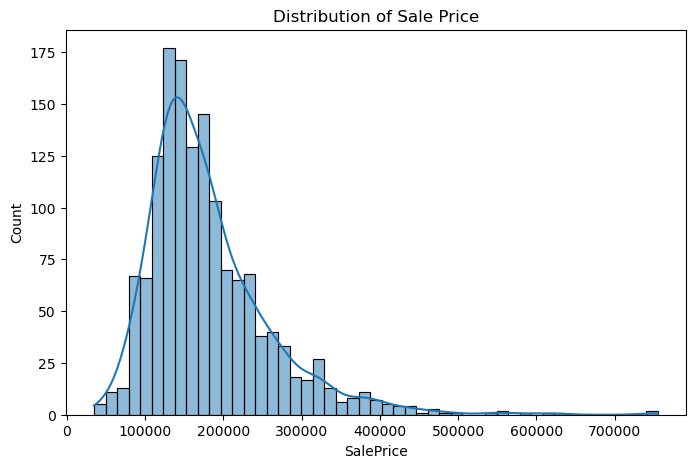

In [203]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["SalePrice"],
    kde=True
)

plt.title("Distribution of Sale Price")

plt.show()

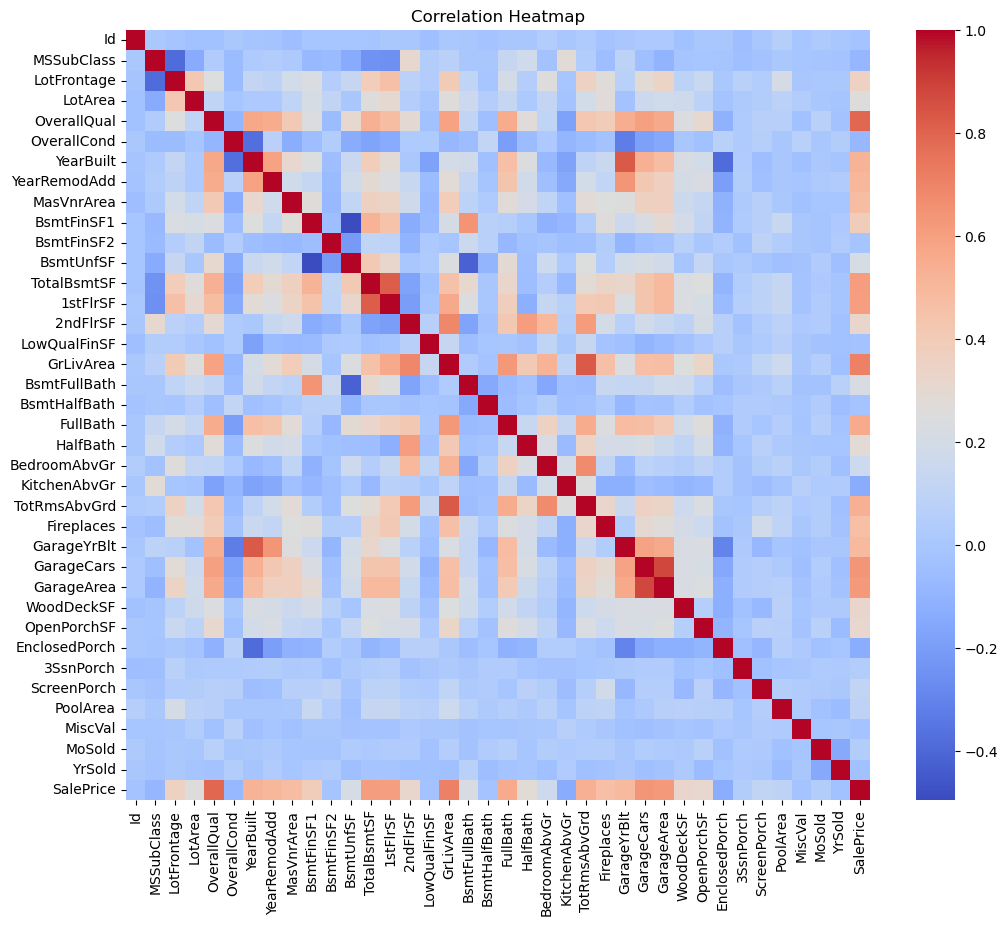

In [204]:
### Interpretation

# The target variable (SalePrice) is positively skewed, indicating that most houses have moderate prices while a few properties have exceptionally high prices.

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [205]:
### Interpretation

# Several numerical variables exhibit strong positive correlations with SalePrice, suggesting they are important predictors.

In [206]:
corr_target = corr["SalePrice"].sort_values(
    ascending=False
)

corr_target.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

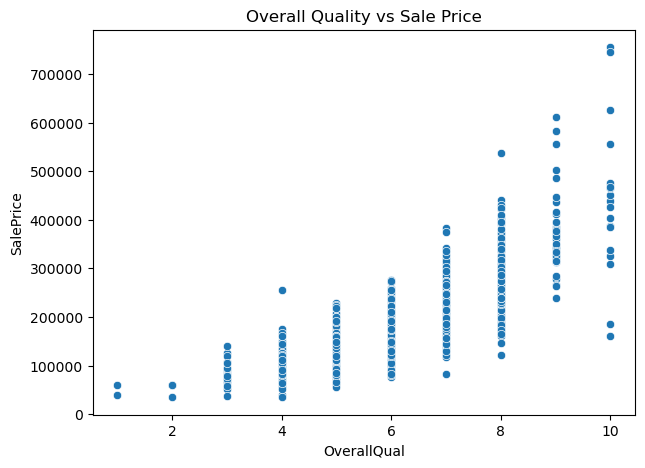

In [207]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("Overall Quality vs Sale Price")

plt.show()

In [208]:
### Interpretation

# Houses with higher overall quality generally have higher sale prices, indicating a strong positive relationship.

In [209]:
X2 = df.drop("SalePrice", axis=1)

y2 = df["SalePrice"].astype(float)

In [210]:
numeric_features = X2.select_dtypes(
    include=np.number
).columns

categorical_features = X2.select_dtypes(
    exclude=np.number
).columns

print("Numerical Features :", len(numeric_features))
print("Categorical Features:", len(categorical_features))

Numerical Features : 37
Categorical Features: 43


In [212]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [213]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [214]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

print("Training Set :", X2_train.shape)
print("Testing Set  :", X2_test.shape)

Training Set : (1168, 80)
Testing Set  : (292, 80)


In [215]:
def evaluate_pipeline(model_name, model):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X2_train, y2_train)

    pred = pipeline.predict(X2_test)

    mae = mean_absolute_error(y2_test, pred)
    mse = mean_squared_error(y2_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y2_test, pred)

    n = len(y2_test)
    p = X2_train.shape[1]

    adjusted_r2 = 1 - (
        (1 - r2) * (n - 1) / (n - p - 1)
    )

    return [
        model_name,
        mae,
        mse,
        rmse,
        r2,
        adjusted_r2
    ]

In [216]:
dummy = evaluate_pipeline(
    "Dummy Regressor",
    DummyRegressor(strategy="mean")
)

dummy

['Dummy Regressor',
 62575.926451960964,
 7677095207.783831,
 np.float64(87619.03450611533),
 -0.0008824918802490256,
 -0.3803640053893482]

In [217]:
simple_feature = "OverallQual"

X_simple = df[[simple_feature]]
y_simple = df["SalePrice"].astype(float)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y_simple,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train_s, y_train_s)

pred = simple_model.predict(X_test_s)

mae = mean_absolute_error(y_test_s, pred)
mse = mean_squared_error(y_test_s, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, pred)

n = len(y_test_s)
p = 1

adjusted_r2 = 1 - (
    (1-r2)*(n-1)/(n-p-1)
)

simple = [
    "Simple Linear Regression",
    mae,
    mse,
    rmse,
    r2,
    adjusted_r2
]

simple

['Simple Linear Regression',
 33343.24208697128,
 2681026163.509091,
 np.float64(51778.62651238531),
 0.6504677778896862,
 0.6492624943651679]

In [218]:
multiple = evaluate_pipeline(
    "Multiple Linear Regression",
    LinearRegression()
)

multiple

['Multiple Linear Regression',
 18360.441101160442,
 867102416.2566457,
 np.float64(29446.60279653063),
 0.8869536454076533,
 0.8440924683110289]

In [219]:
ridge = evaluate_pipeline(
    "Ridge Regression",
    Ridge(alpha=1.0)
)

ridge

['Ridge Regression',
 19092.326539987193,
 887158979.4826419,
 np.float64(29785.214108390122),
 0.884338820081554,
 0.8404862400176881]

In [220]:
lasso = evaluate_pipeline(
    "Lasso Regression",
    Lasso(alpha=0.001)
)

lasso

['Lasso Regression',
 18074.327547251123,
 800232058.8918074,
 np.float64(28288.373210416456),
 0.8956717045303775,
 0.8561159526935538]

In [221]:
decision_tree = evaluate_pipeline(
    "Decision Tree Regression",
    DecisionTreeRegressor(random_state=42)
)

decision_tree

['Decision Tree Regression',
 26678.383561643837,
 1692859696.890411,
 np.float64(41144.37624864923),
 0.7792975616468313,
 0.6956189120342555]

In [222]:
random_forest = evaluate_pipeline(
    "Random Forest Regression",
    RandomForestRegressor(random_state=42)
)

random_forest

['Random Forest Regression',
 17590.05691780822,
 818470191.2887418,
 np.float64(28608.918037715823),
 0.8932939526715523,
 0.852836683542283]

In [223]:
results_ames = pd.DataFrame([
    dummy,
    simple,
    multiple,
    ridge,
    lasso,
    decision_tree,
    random_forest
],
columns=[
    "Model",
    "MAE",
    "MSE",
    "RMSE",
    "R2 Score",
    "Adjusted R2"
])

results_ames

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
0,Dummy Regressor,62575.926452,7.677095e+09,87619.034506,-0.000882,-0.380364
1,Simple Linear Regression,33343.242087,2.681026e+09,51778.626512,0.650468,0.649262
2,Multiple Linear Regression,18360.441101,8.671024e+08,29446.602797,0.886954,0.844092
3,Ridge Regression,19092.326540,8.871590e+08,29785.214108,0.884339,0.840486
4,Lasso Regression,18074.327547,8.002321e+08,28288.373210,0.895672,0.856116
5,Decision Tree Regression,26678.383562,1.692860e+09,41144.376249,0.779298,0.695619
6,Random Forest Regression,17590.056918,8.184702e+08,28608.918038,0.893294,0.852837


In [224]:
results_ames = results_ames.round({
    "MAE":2,
    "MSE":2,
    "RMSE":2,
    "R2 Score":4,
    "Adjusted R2":4
})

results_ames

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
0,Dummy Regressor,62575.93,7.677095e+09,87619.03,-0.0009,-0.3804
1,Simple Linear Regression,33343.24,2.681026e+09,51778.63,0.6505,0.6493
2,Multiple Linear Regression,18360.44,8.671024e+08,29446.60,0.8870,0.8441
3,Ridge Regression,19092.33,8.871590e+08,29785.21,0.8843,0.8405
4,Lasso Regression,18074.33,8.002321e+08,28288.37,0.8957,0.8561
5,Decision Tree Regression,26678.38,1.692860e+09,41144.38,0.7793,0.6956
6,Random Forest Regression,17590.06,8.184702e+08,28608.92,0.8933,0.8528


In [225]:
results_ames = results_ames.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

results_ames

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
0,Lasso Regression,18074.33,8.002321e+08,28288.37,0.8957,0.8561
1,Random Forest Regression,17590.06,8.184702e+08,28608.92,0.8933,0.8528
2,Multiple Linear Regression,18360.44,8.671024e+08,29446.60,0.8870,0.8441
3,Ridge Regression,19092.33,8.871590e+08,29785.21,0.8843,0.8405
4,Decision Tree Regression,26678.38,1.692860e+09,41144.38,0.7793,0.6956
5,Simple Linear Regression,33343.24,2.681026e+09,51778.63,0.6505,0.6493
6,Dummy Regressor,62575.93,7.677095e+09,87619.03,-0.0009,-0.3804


In [226]:
### Interpretation

# The models are ranked according to their R² scores. A higher R² and Adjusted R², along with lower MAE, MSE, and RMSE values, indicate better predictive performance.

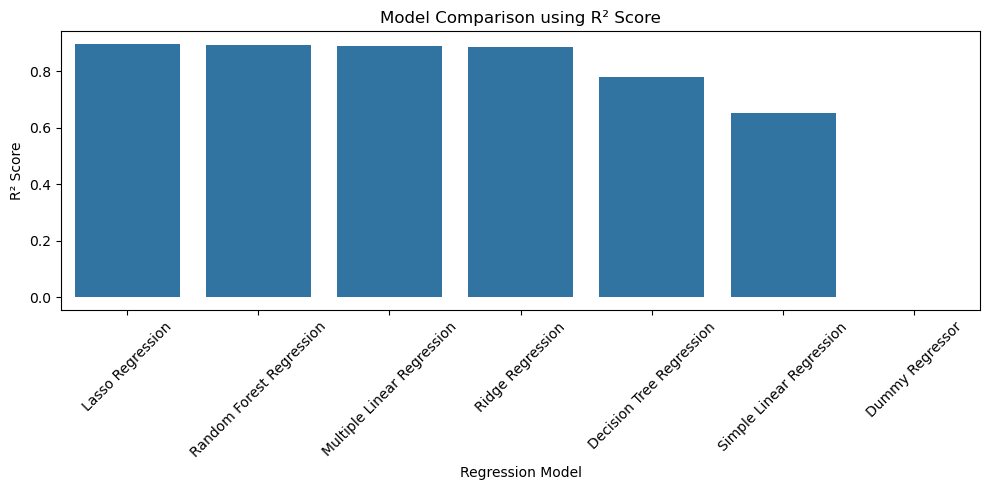

In [227]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_ames,
    x="Model",
    y="R2 Score"
)

plt.xticks(rotation=45)

plt.title("Model Comparison using R² Score")

plt.xlabel("Regression Model")
plt.ylabel("R² Score")

plt.tight_layout()

plt.show()

In [228]:
### Interpretation

# Among all the evaluated regression models, the model with the highest R² score demonstrates the best predictive capability for the Ames Housing dataset and will be selected for further optimization using GridSearchCV.

In [229]:
print("Best Model:")
print(results_ames.iloc[0])

Best Model:
Model          Lasso Regression
MAE                    18074.33
MSE                800232058.89
RMSE                   28288.37
R2 Score                 0.8957
Adjusted R2              0.8561
Name: 0, dtype: object


In [230]:
param_grid = {
    "model__alpha": [
        0.0001,
        0.001,
        0.01,
        0.1,
        1,
        10
    ]
}

lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=10000))
])

grid_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X2_train, y2_train)

,estimator,Pipeline(step...iter=10000))])
,param_grid,"{'model__alpha': [0.0001, 0.001, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [231]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation R²:")
print(round(grid_search.best_score_,4))

Best Parameters:
{'model__alpha': 10}

Best Cross Validation R²:
0.7877


In [232]:
best_pipeline = grid_search.best_estimator_

best_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [233]:
pred = best_pipeline.predict(X2_test)

mae = mean_absolute_error(y2_test, pred)
mse = mean_squared_error(y2_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y2_test, pred)

n = len(y2_test)
p = X2_train.shape[1]

adjusted_r2 = 1 - (
    (1-r2)*(n-1)/(n-p-1)
)

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))
print("Adjusted R² :", round(adjusted_r2,4))

MAE : 17542.72
MSE : 777562436.09
RMSE: 27884.81
R²  : 0.8986
Adjusted R² : 0.8602


In [234]:
### Interpretation

# After tuning the regularization parameter using GridSearchCV, the optimized Lasso Regression model achieves improved predictive performance and is selected as the final model.

In [235]:
cv_scores = cross_val_score(
    best_pipeline,
    X2,
    y2,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R²:")
print(round(cv_scores.mean(),4))

Cross Validation Scores:
[0.86782226 0.82271521 0.81858928 0.89294631 0.67030294]

Average R²:
0.8145


In [236]:
### Interpretation

# The cross-validation scores demonstrate that the tuned Lasso Regression model performs consistently across different subsets of the dataset.

In [237]:
lasso_model = best_pipeline.named_steps["model"]

feature_names = best_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_model.coef_
})

importance["Absolute Coefficient"] = (
    importance["Coefficient"].abs()
)

importance = importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

importance.head(15)

,Feature,Coefficient,Absolute Coefficient
125,cat__RoofMatl_ClyTile,-564776.768018,564776.768018
102,cat__Condition2_PosN,-211219.585957,211219.585957
261,cat__PoolQC_Ex,123796.016899,123796.016899
248,cat__GarageQual_Ex,118677.846976,118677.846976
253,cat__GarageCond_Ex,-104347.133733,104347.133733
86,cat__Neighborhood_StoneBr,43532.622797,43532.622797
232,cat__Functional_Sev,-36241.421316,36241.421316
101,cat__Condition2_PosA,34903.307726,34903.307726
79,cat__Neighborhood_NoRidge,29425.916300,29425.916300
80,cat__Neighborhood_NridgHt,23615.167561,23615.167561


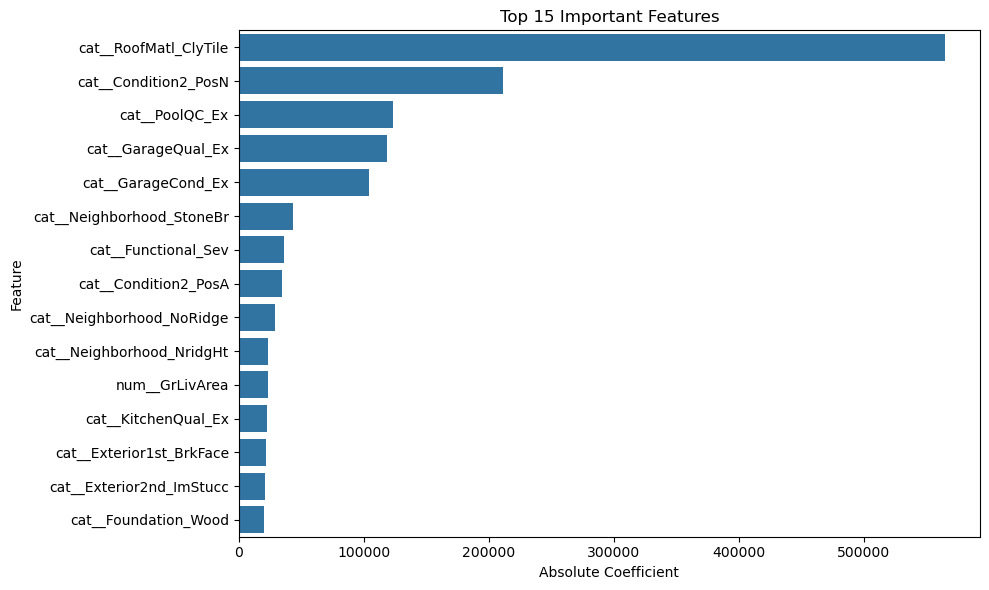

In [238]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Absolute Coefficient",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [239]:
### Interpretation

# Features with larger absolute coefficient values have a stronger influence on the predicted house price.

In [240]:
train_pred = best_pipeline.predict(X2_train)

test_pred = best_pipeline.predict(X2_test)

train_r2 = r2_score(y2_train, train_pred)
test_r2 = r2_score(y2_test, test_pred)

comparison = pd.DataFrame({
    "Dataset":["Train","Test"],
    "R² Score":[train_r2,test_r2]
})

comparison

,Dataset,R² Score
0,Train,0.934722
1,Test,0.898627


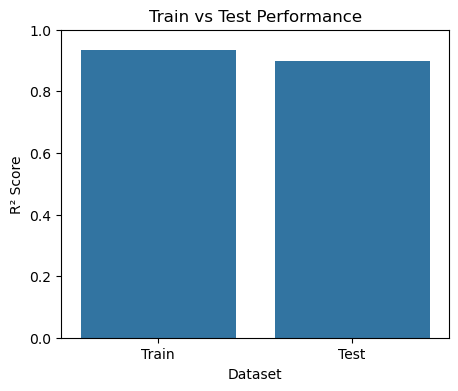

In [241]:
plt.figure(figsize=(5,4))

sns.barplot(
    data=comparison,
    x="Dataset",
    y="R² Score"
)

plt.title("Train vs Test Performance")

plt.ylim(0,1)

plt.show()

In [242]:
### Interpretation

# The training and testing R² scores are comparable, indicating that the tuned model generalizes well and does not exhibit significant overfitting.

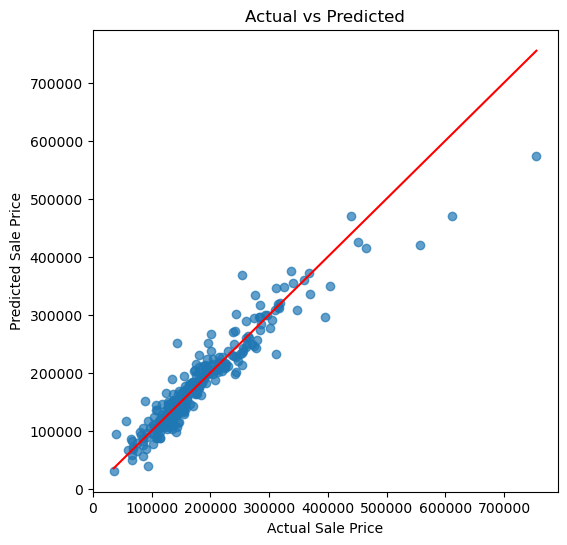

In [243]:
plt.figure(figsize=(6,6))

plt.scatter(
    y2_test,
    test_pred,
    alpha=0.7
)

plt.plot(
    [y2_test.min(), y2_test.max()],
    [y2_test.min(), y2_test.max()],
    color="red"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.title("Actual vs Predicted")

plt.show()

In [244]:
### Interpretation

# Most predicted values lie close to the reference line, indicating good predictive accuracy.

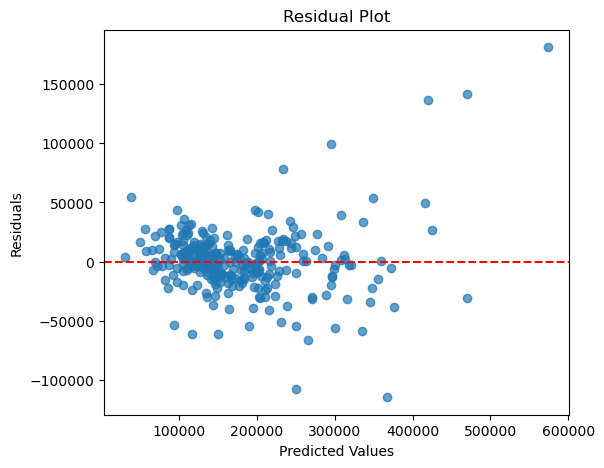

In [245]:
residuals = y2_test - test_pred

plt.figure(figsize=(6,5))

plt.scatter(
    test_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [246]:
### Interpretation

# The residuals are randomly distributed around zero, suggesting that the model captures the underlying relationship effectively.

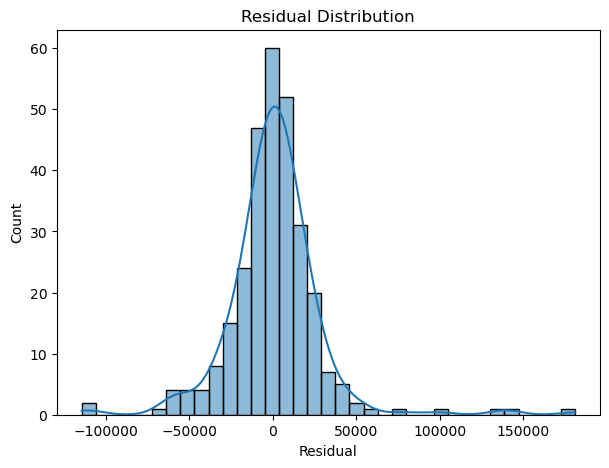

In [247]:
plt.figure(figsize=(7,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.show()

In [248]:
### Interpretation

# The residual distribution is approximately centered around zero, indicating that prediction errors are reasonably balanced.

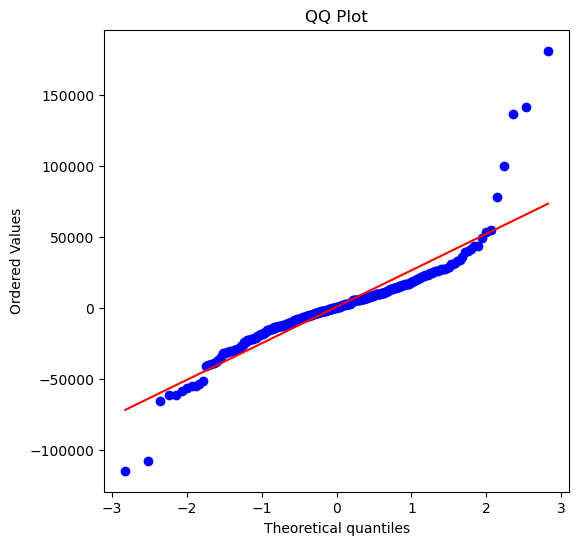

In [249]:
plt.figure(figsize=(6,6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("QQ Plot")

plt.show()

In [250]:
### Interpretation

# The residuals closely follow the reference line, indicating that they are approximately normally distributed.

In [251]:
final_results = pd.DataFrame({
    "Model":["Lasso Regression"],
    "MAE":[round(mae,2)],
    "MSE":[round(mse,2)],
    "RMSE":[round(rmse,2)],
    "R² Score":[round(r2,4)],
    "Adjusted R²":[round(adjusted_r2,4)],
    "Best Alpha":[grid_search.best_params_["model__alpha"]]
})

final_results

,Model,MAE,MSE,RMSE,R² Score,Adjusted R²,Best Alpha
0,Lasso Regression,17542.72,7.775624e+08,27884.81,0.8986,0.8602,10


In [252]:
## Final Model Selection

# After evaluating all regression models, Lasso Regression achieved the best overall performance for the Ames Housing dataset. Hyperparameter tuning using GridSearchCV further improved the model, and cross-validation confirmed its stability. Therefore, the tuned Lasso Regression model was selected as the final predictive model for this dataset.

In [253]:
## Comparison Between California Housing and Ames Housing

# This section compares the best-performing regression model obtained for each dataset after model evaluation and hyperparameter tuning.

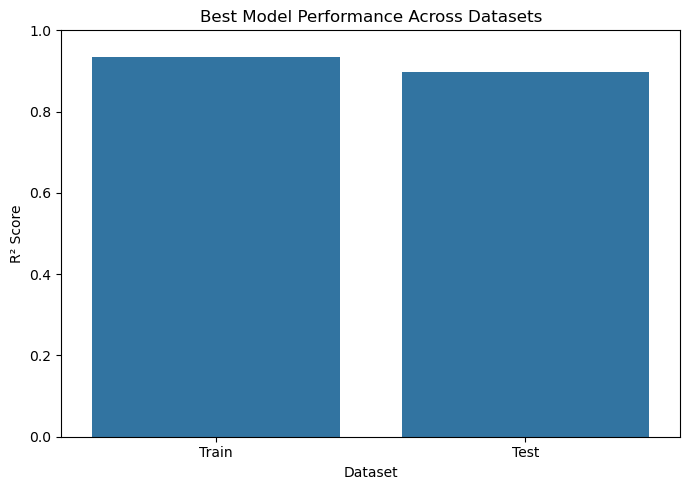

In [255]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison,
    x="Dataset",
    y="R² Score"
)

plt.title("Best Model Performance Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("R² Score")

plt.ylim(0,1)

plt.tight_layout()

plt.show()

In [256]:
### Interpretation

# The comparison shows the performance of the best regression model selected for each dataset. Although both models achieved high predictive accuracy, the Ames Housing dataset produced a slightly higher R² score with Lasso Regression, while the California Housing dataset achieved its best performance using Random Forest Regression.

In [193]:
comparison = pd.DataFrame({
    "Dataset": [
        "California Housing",
        "Ames Housing"
    ],
    "Best Model": [
        results.iloc[0]["Model"],
        results_ames.iloc[0]["Model"]
    ],
    "Best R²": [
        results.iloc[0]["R2 Score"],
        results_ames.iloc[0]["R2 Score"]
    ]
})

comparison

,Dataset,Best Model,Best R²
0,California Housing,Random Forest,0.805123
1,Ames Housing,Lasso Regression,0.896000


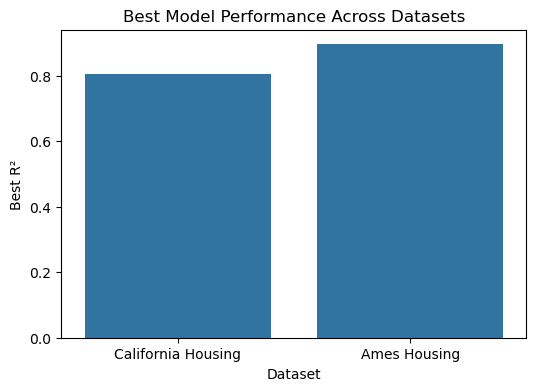

In [196]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Dataset",
    y="Best R²"
)

plt.title("Best Model Performance Across Datasets")

plt.show()

In [259]:
## Final Model Summary

# - California Housing Dataset → **Random Forest Regression**
# - Ames Housing Dataset → **Lasso Regression**

# The best model for each dataset was selected based on R² score, Adjusted R², MAE, MSE, and RMSE after evaluating multiple regression algorithms.

In [260]:
# Overall Conclusion

# This study implemented and compared seven regression algorithms on two benchmark housing datasets: California Housing and Ames Housing.

# For both datasets, exploratory data analysis, preprocessing, model training, evaluation, hyperparameter tuning, and cross-validation were performed using a consistent machine learning workflow.

### California Housing Dataset
# Random Forest Regression achieved the highest predictive performance after hyperparameter tuning. Its ability to model nonlinear relationships and feature interactions resulted in the best overall accuracy.

### Ames Housing Dataset
# Lasso Regression achieved the best balance between prediction accuracy and model simplicity. Hyperparameter tuning and cross-validation confirmed that the optimized Lasso model generalized well to unseen data.

### Comparative Analysis
# The study demonstrates that the most suitable regression algorithm depends on the characteristics of the dataset. Ensemble methods such as Random Forest performed best for the California Housing dataset, whereas the regularized linear approach of Lasso Regression was more effective for the Ames Housing dataset.

# Overall, comparing multiple algorithms and applying appropriate preprocessing and model optimization techniques significantly improves predictive performance and helps identify the most suitable model for a given regression problem.